In [13]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Breast Cancer Dataset from Scikit-learn
data = load_breast_cancer()

# Accessing properties using dictionary keys to remove VS Code red lines
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target'] # 0 = Malignant, 1 = Benign

print("--- Step 1: Dataset Loaded Successfully ---")
print(f"Dataset Features Shape: {X.shape[0]} rows, {X.shape[1]} columns.")
print(f"Target Classes: {data['target_names']} (0 = Malignant, 1 = Benign)\n")

--- Step 1: Dataset Loaded Successfully ---
Dataset Features Shape: 569 rows, 30 columns.
Target Classes: ['malignant' 'benign'] (0 = Malignant, 1 = Benign)



In [8]:
# 2. Split data into training and testing sets
# 80% Training data, 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("--- Step 2: Data Split Complete ---")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")

--- Step 2: Data Split Complete ---
Training set size: 455 samples
Testing set size: 114 samples



In [9]:
# 3. Train the Logistic Regression model
# We set max_iter=3000 to ensure the optimization algorithm fully converges
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)
print("--- Step 3: Logistic Regression Model Trained ---\n")

--- Step 3: Logistic Regression Model Trained ---



In [10]:
# 4. Predict classes for the test set
y_pred = model.predict(X_test)

In [11]:
# 5. Evaluate accuracy and generate reports
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=data.target_names)

print("--- Step 4 & 5: Model Evaluation ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(class_report)

# Save the Classification Report text file as requested in deliverables
with open("classification_report.txt", "w") as f:
    f.write("=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===\n\n")
    f.write(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n\n")
    f.write(class_report)
print("Success! 'classification_report.txt' has been saved locally.\n")

--- Step 4 & 5: Model Evaluation ---
Model Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Success! 'classification_report.txt' has been saved locally.



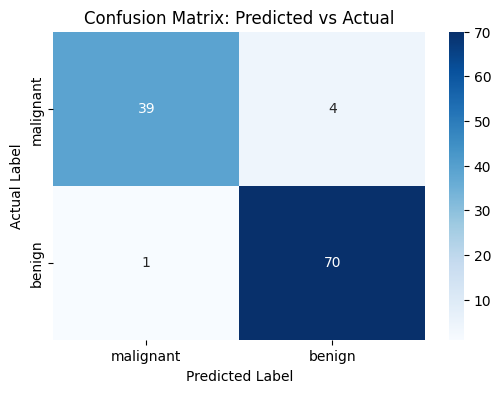

In [12]:
# Optional Visual: Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()